In [1]:
import serial
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from scipy.fft import rfft
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,RandomizedSearchCV,GridSearchCV,cross_validate
from sklearn.metrics import classification_report, confusion_matrix,f1_score
from sklearn.pipeline import make_pipeline
load_dotenv()  
from scipy import stats

In [ ]:
with serial.Serial(os.getenv('port'), 115200, timeout=2) as ser:
    ser.reset_input_buffer()
    data_chunks = []

    for i in range(120):
        # 1. Hunt for the 0xAA 0x55 sync marker to align the frame
        while True:
            if ser.read(1) == b'\xAA':
                if ser.read(1) == b'\x55':
                    break
        
        # 2. Extract exactly the 6000 byte payload
        raw = ser.read(6000)
        if len(raw) < 6000:
            print("Warning: Incomplete packet received, skipping...")
            continue
            
        parsed = np.frombuffer(raw, dtype='>i2')
        reshaped = parsed.reshape(-1, 3)
        print(reshaped)
        data_chunks.append(reshaped)

            
final_matrix = np.vstack(data_chunks)
df = pd.DataFrame(final_matrix, columns=['Accel_X', 'Accel_Y', 'Accel_Z'])
df = df / 16384.0

# df.to_csv(//your path//, index=False)  # Uncomment and specify your path to save the DataFrame
print(df.head(15))
print(f"Total shape: {df.shape}")

CONVERTING EACH CLASS INTO ITS OWN DATASET

In [2]:
main_path = os.getenv('main_path')
window_size = 128
cols = ['Variance_X', 'Variance_Y', 'Variance_Z', 'RMS_X', 'RMS_Y', 'RMS_Z', 'PtP_X', 'PtP_Y', 'PtP_Z', 'Dominant_X', 'Dominant_Y', 'Dominant_Z','Spec_Crest_X','Spec_Crest_Y','Spec_Crest_Z']

In [145]:
for classes in os.listdir(main_path):
    final_df = pd.DataFrame(columns=cols)
    features_list = []
    for filename in os.listdir(os.path.join(main_path,classes)):
        if not filename.endswith('.csv') or filename.startswith('final_'):
            continue
        curr_df = pd.read_csv(os.path.join(main_path,classes,filename))
        for i in range(0,len(curr_df),window_size):
            if(i+window_size > len(curr_df)):
                break
            window = curr_df.iloc[i:i+window_size].values
            mean = window.mean(axis=0)
            window = window - mean
            variance = np.var(window, axis=0)
            rms = np.sqrt(np.mean(window**2, axis=0))
            ptp = np.ptp(window, axis=0)
            fft_mags = np.abs(rfft(window, axis=0))
            dominant_freq = np.argmax(fft_mags, axis=0)
            spectral_crest = np.max(fft_mags, axis=0) / (np.mean(fft_mags, axis=0) + 1e-8)
            features = np.concatenate([variance, rms, ptp, dominant_freq,spectral_crest],axis=0).reshape(1,-1) 
            features_list.append(features)

    final_df = pd.DataFrame(np.vstack(features_list), columns=cols)
    final_df['Label'] = classes
    final_df.to_csv(os.path.join(main_path,classes,'_'.join(["final",classes,"dataset.csv"])),index=False)

VISUALISING EACH CLASS DIFFERENCES

Visualizing feature distributions for class: Bearing_Fault


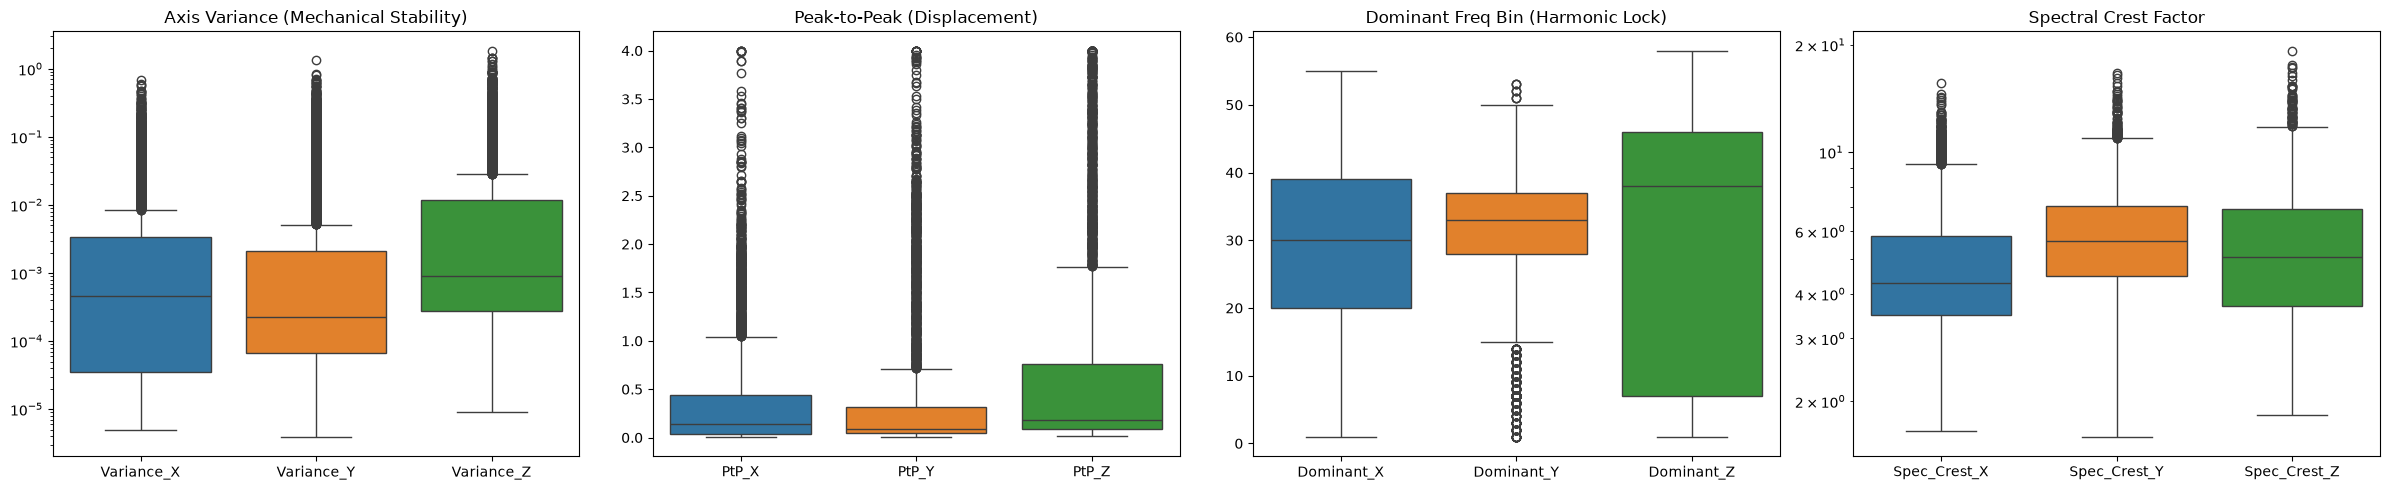

        Dominant_Z  Spec_Crest_Z
count  4669.000000   4669.000000
mean     29.605697      5.547805
std      18.494221      2.302655
min       1.000000      1.829514
25%       7.000000      3.709987
50%      38.000000      5.086056
75%      46.000000      6.944909
max      58.000000     19.267195
Visualizing feature distributions for class: Healthy


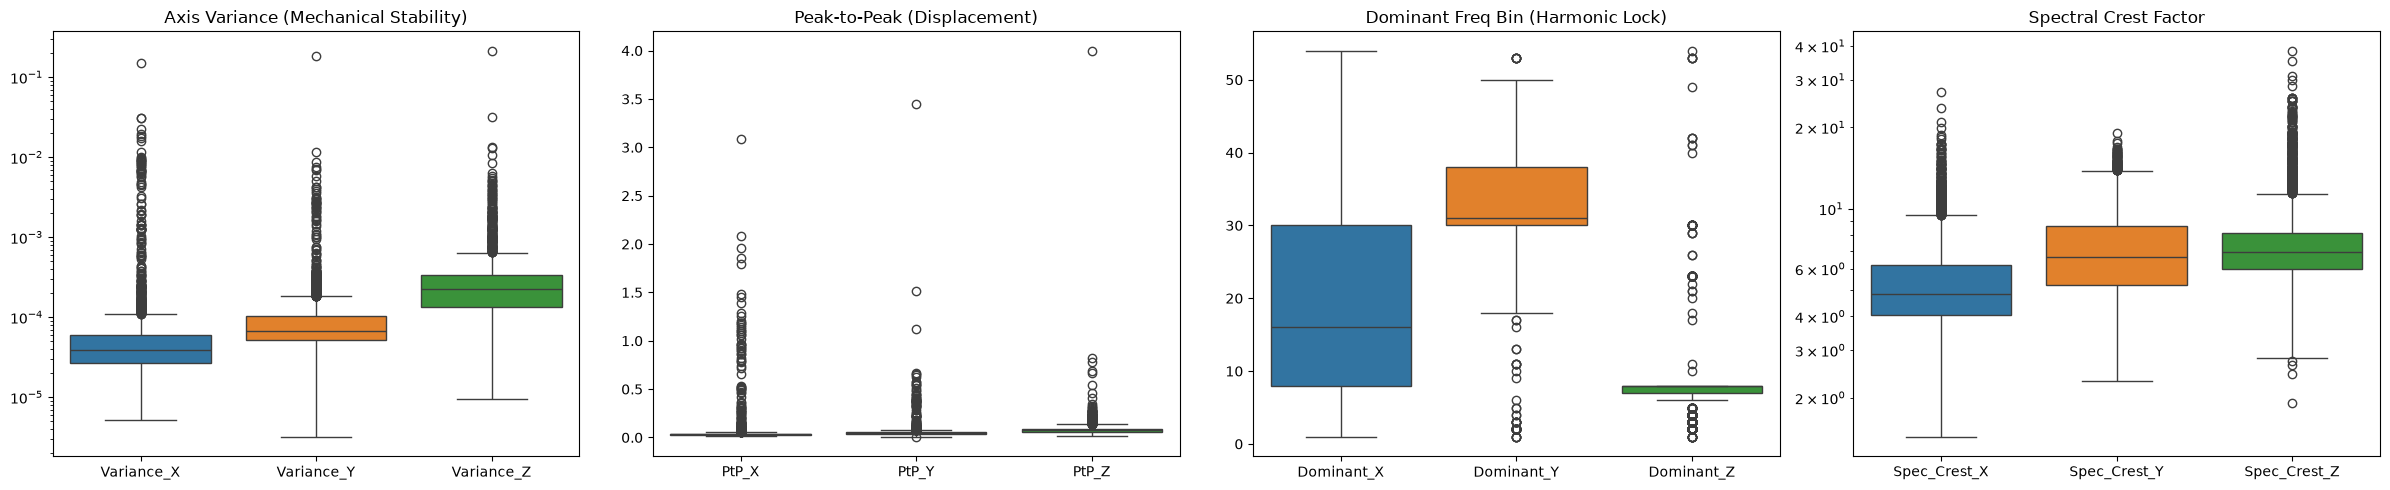

        Dominant_Z  Spec_Crest_Z
count  4677.000000   4677.000000
mean      6.977122      7.560779
std       3.716555      2.910070
min       1.000000      1.915620
25%       7.000000      6.003171
50%       8.000000      6.942523
75%       8.000000      8.159078
max      54.000000     38.430437
Visualizing feature distributions for class: Imbalance


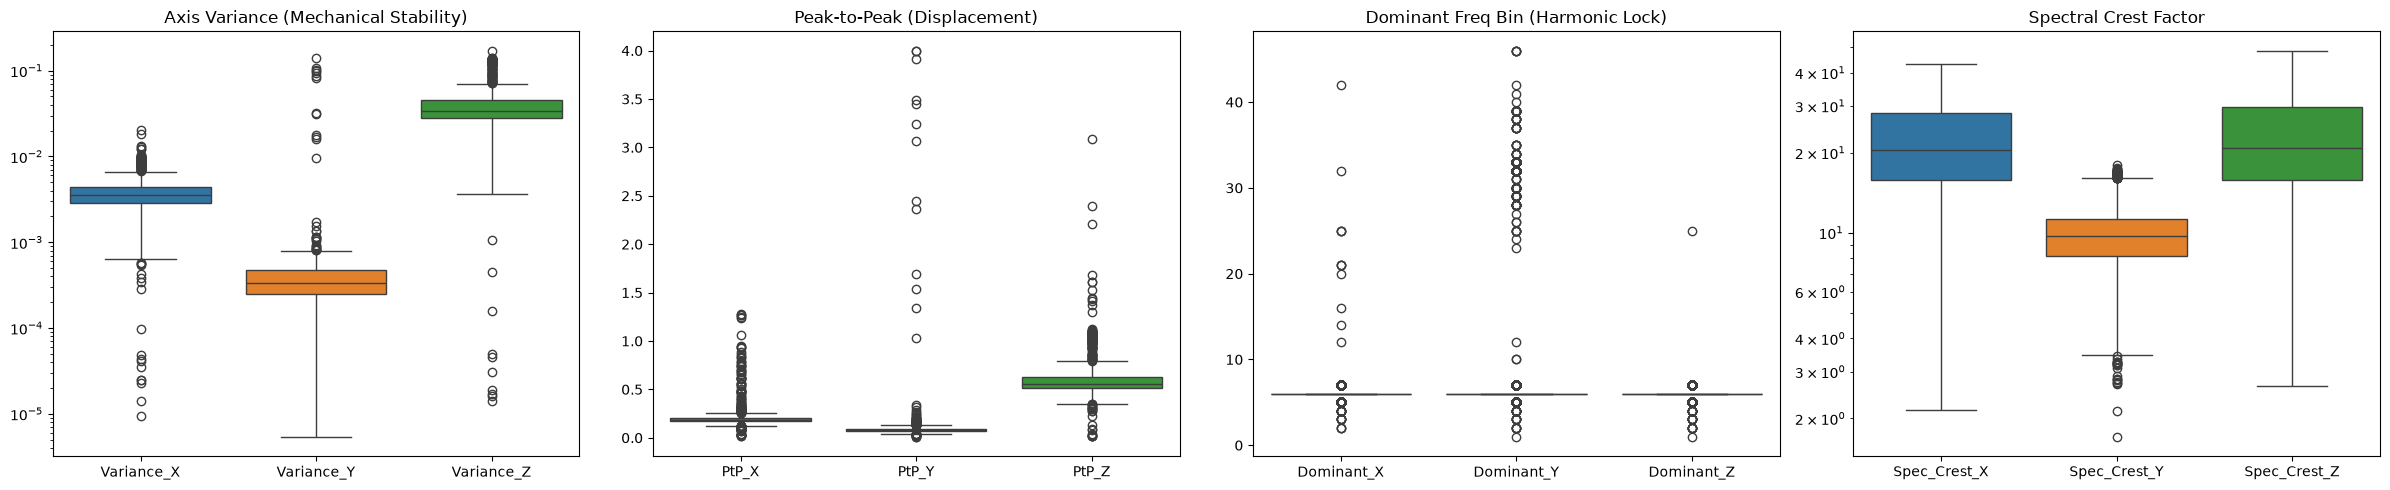

        Dominant_Z  Spec_Crest_Z
count  4685.000000   4685.000000
mean      5.867236     23.243181
std       0.639475      8.714802
min       1.000000      2.636994
25%       6.000000     15.787839
50%       6.000000     20.792655
75%       6.000000     29.762047
max      25.000000     48.416117
Visualizing feature distributions for class: Transient_Shock


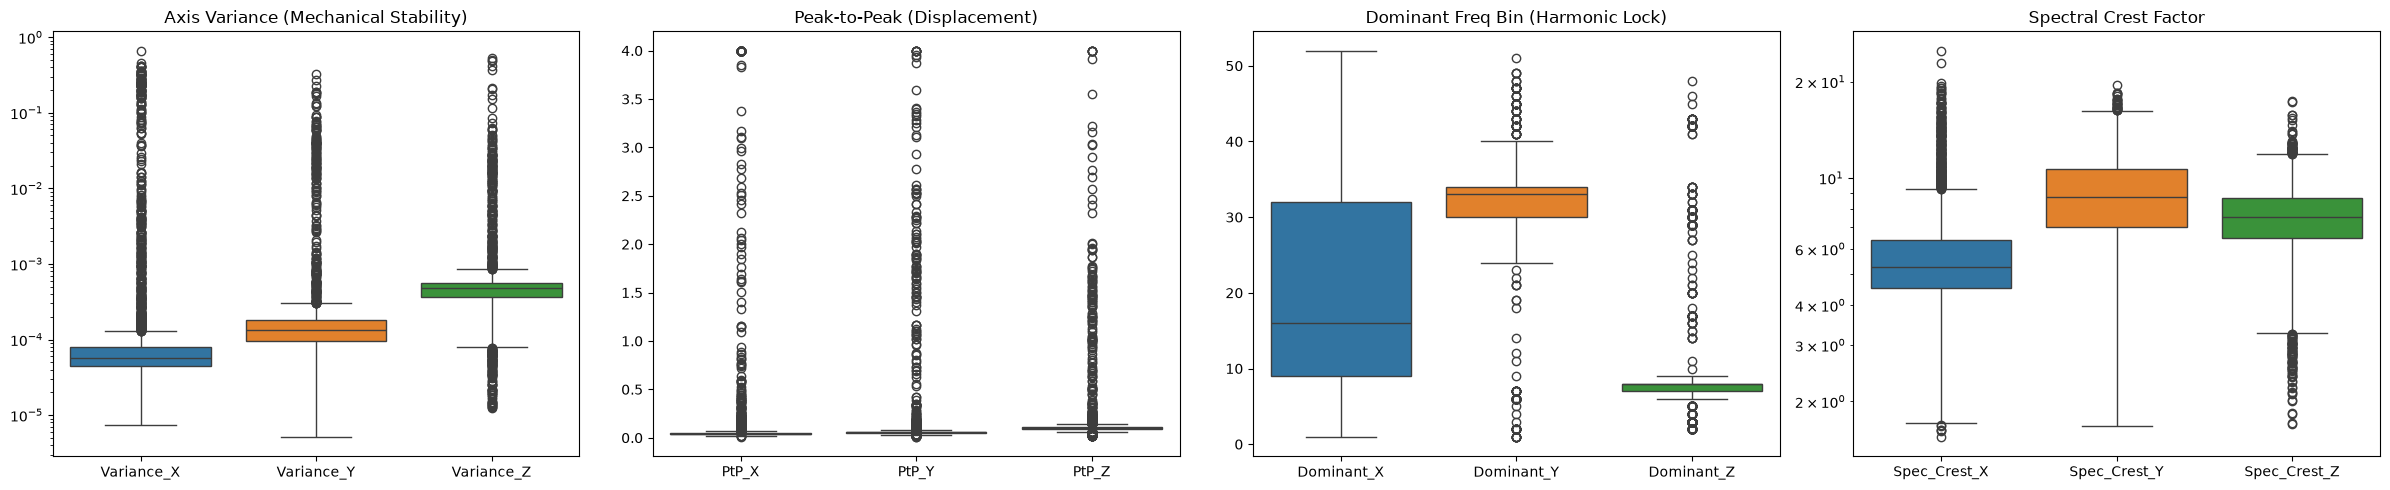

        Dominant_Z  Spec_Crest_Z
count  3700.000000   3700.000000
mean      9.124054      7.611681
std       6.455539      1.744756
min       2.000000      1.696047
25%       7.000000      6.499745
50%       8.000000      7.526955
75%       8.000000      8.662233
max      48.000000     17.409440


In [146]:
for classes in os.listdir(main_path):
    class_dir = os.path.join(main_path, classes)
    if not os.path.isdir(class_dir):
        continue
        
    for filename in os.listdir(class_dir):
        if not filename.startswith("final_"):
            continue
            
        file_path = os.path.join(class_dir, filename)
        df = pd.read_csv(file_path)

        # 1. Expanded visualization grid to 4 panels
        fig, axes = plt.subplots(1, 4, figsize=(24, 5))
        print(f"Visualizing feature distributions for class: {classes}")

        # 2. Variance Check
        sns.boxplot(data=df[['Variance_X', 'Variance_Y', 'Variance_Z']], ax=axes[0])
        axes[0].set_title('Axis Variance (Mechanical Stability)')
        axes[0].set_yscale('log')

        # 3. Peak-to-Peak (PtP) Check (Fixed your 'Ptp_Y' typo)
        sns.boxplot(data=df[['PtP_X', 'PtP_Y', 'PtP_Z']], ax=axes[1])
        axes[1].set_title('Peak-to-Peak (Displacement)')

        # 4. Dominant Frequency (Identifies tonal harmonics vs broadband)
        sns.boxplot(data=df[['Dominant_X','Dominant_Y', 'Dominant_Z']], ax=axes[2])
        axes[2].set_title('Dominant Freq Bin (Harmonic Lock)')

        # 5. Spectral Crest Factor (Separates impacts from continuous drag)
        sns.boxplot(data=df[['Spec_Crest_X','Spec_Crest_Y','Spec_Crest_Z']], ax=axes[3])
        axes[3].set_title('Spectral Crest Factor')
        axes[3].set_yscale('log')

        plt.tight_layout()
        plt.show()

        # 6. Statistical hard-check focuses strictly on the new spectral features
        print(df[['Dominant_Z', 'Spec_Crest_Z']].describe())

MASTER DATASET 

In [147]:
master_data = pd.DataFrame(columns=cols)
for classes in os.listdir(main_path):
    for filename in os.listdir(os.path.join(main_path,classes)):
        if not filename.startswith("final_"):
            continue
        df = pd.read_csv(os.path.join(main_path,classes,filename))
        master_data = pd.concat([master_data, df], ignore_index=True)
master_data.to_csv(os.path.join(main_path,'master_dataset.csv'),index=False)
master_data.shape
master_data[['Label']].value_counts()

Label          
Imbalance          4685
Healthy            4677
Bearing_Fault      4669
Transient_Shock    3700
Name: count, dtype: int64

In [14]:
master_data = pd.read_csv(os.path.join(main_path,'master_dataset.csv'))
print(master_data.isna().sum())  
print(len(master_data.columns))
print(master_data.shape)

Variance_X      0
Variance_Y      0
Variance_Z      0
RMS_X           0
RMS_Y           0
RMS_Z           0
PtP_X           0
PtP_Y           0
PtP_Z           0
Dominant_X      0
Dominant_Y      0
Dominant_Z      0
Spec_Crest_X    0
Spec_Crest_Y    0
Spec_Crest_Z    0
Label           0
dtype: int64
16
(17731, 16)


TRAINING THE DECISION TREE MODEL

In [4]:
labels = master_data['Label'].unique()
X = master_data.loc[:,"Variance_X":"Spec_Crest_Z"]
y = master_data["Label"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
fold = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
param_grid = {
    "max_depth": [5, 10, 15,20],
    "max_features": [5,7,9,11,None],
}
classifier = DecisionTreeClassifier(criterion="gini")
cv = GridSearchCV(estimator=classifier,param_grid=param_grid,n_jobs=-1,cv=fold,scoring="f1_macro")

cv.fit(X_train,y_train)
print(f"Best Parameters: {cv.best_params_}")
print(f"F1 Score: {cv.best_score_}")
pred = cv.predict(X_test)

print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred,labels=labels))


print(f"Train Accuracy: {cv.best_estimator_.score(X_train,y_train)}")
print(f"Test Accuracy: {cv.best_estimator_.score(X_test,y_test)}")
print(f"Predicted Probabilities: {len(cv.predict_proba(X_test))}")


Best Parameters: {'max_depth': 20, 'max_features': 11}
F1 Score: 0.9136340863407936
                 precision    recall  f1-score   support

  Bearing_Fault       0.90      0.90      0.90      1401
        Healthy       0.89      0.90      0.90      1403
      Imbalance       1.00      1.00      1.00      1406
Transient_Shock       0.89      0.88      0.88      1110

       accuracy                           0.92      5320
      macro avg       0.92      0.92      0.92      5320
   weighted avg       0.92      0.92      0.92      5320

[[1265   77    0   59]
 [  76 1266    1   60]
 [   1    2 1399    4]
 [  62   70    0  978]]
Train Accuracy: 0.9970993473531544
Test Accuracy: 0.9225563909774436
Predicted Probabilities: 5320


In [5]:
print(f"{cross_val_score(cv.best_estimator_,X_train,y_train,cv=fold,scoring='f1_macro')/5}")
print(f"Variance: {cv.best_estimator_.feature_importances_}")
print(f"Train Recall: {f1_score(y_train,cv.predict(X_train),labels=labels,average='macro')}")
print(f"Test Recall: {f1_score(y_test,pred,labels=labels,average='macro')}")


[0.18164909 0.18200832 0.18274953]
Variance: [0.02326944 0.00970925 0.01393133 0.14989804 0.07553382 0.12794774
 0.0205603  0.00893233 0.01274376 0.03603311 0.08830032 0.06799294
 0.32378099 0.02170943 0.01965721]
Train Recall: 0.99694677053125
Test Recall: 0.9205717258280312


since here we can see that one feature is dominating with 0.32 meaning it is not meaningful to use standard bagging hence we will use RANDOM FOREST

In [6]:
MAX_F1_DROP = 0.015    # Will not accept a model that is 1.5% worse than the absolute best
MAX_TREES = 120        # Firmware Flash limit
MAX_DEPTH = 12
MAX_FLASH_BYTES = 400 * 1024  
MIN_F1_SCORE = 0.90
MAX_DEPTH_MAX = 12
MAX_DEPTH_MIN = 5
MAX_FEATURES_MAX = 11
MAX_FEATURES_MIN = 3
N_ESTIMATORS_MAX = 200
N_ESTIMATORS_MIN = 50
MIN_SAMPLES_LEAF_MAX = 10
MIN_SAMPLES_LEAF_MIN = 1

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
rf = RandomForestClassifier(n_jobs=-1,oob_score=True,random_state=42)
fold = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
max_attempt = 4

rf_param_grid = {
    "max_depth" : stats.randint(MAX_DEPTH_MIN,MAX_DEPTH_MAX),
    "max_features" : stats.randint(MAX_FEATURES_MIN,MAX_FEATURES_MAX),
    "min_samples_leaf":stats.randint(MIN_SAMPLES_LEAF_MIN, MIN_SAMPLES_LEAF_MAX),
    "n_estimators" : stats.randint(N_ESTIMATORS_MIN,N_ESTIMATORS_MAX)
}

In [ ]:
viable_models = []
for i in range(max_attempt):
    print(f"Attempt {i} of {max_attempt}")
    cv = RandomizedSearchCV(estimator=rf,scoring ="f1_macro",param_distributions=rf_param_grid,n_iter=30,cv=fold,random_state=42,verbose=3,n_jobs=4)
    cv.fit(X_train,y_train)
    
    results = pd.DataFrame(cv.cv_results_)
    results = results[results['mean_test_score'] >= MIN_F1_SCORE]
    
    for _,row in results.iterrows():
        temp_model = RandomForestClassifier(
            max_depth=row['param_max_depth'],
            max_features=row['param_max_features'],
            n_estimators=row['param_n_estimators'],
            min_samples_leaf=row['param_min_samples_leaf'],
            random_state=42
        )
        temp_model.fit(X_train, y_train)
        total_nodes = sum(t.tree_.node_count for t in temp_model.estimators_)
        flash_bytes = total_nodes * 12  # float (12 bytes per node)
            
        if flash_bytes <= MAX_FLASH_BYTES:
            viable_models.append({
                'params': row['params'],
                'score': row['mean_test_score'],
                'nodes': total_nodes,
                'flash_kb': flash_bytes / 1024
            })
            
    if not viable_models:
        max_attempt -= 1
        print("No model found. Adjusting hyper-parameters")   
        rf_param_grid = {
            "max_depth" : stats.randint(MAX_DEPTH_MIN ,MAX_DEPTH_MAX-1),
            "max_features" : stats.randint(MAX_FEATURES_MIN,MAX_FEATURES_MAX-2),
            "n_estimators" : stats.randint(N_ESTIMATORS_MIN,N_ESTIMATORS_MAX-30)
        }
    else:
        viable_models_df = pd.DataFrame(viable_models)
        viable_models_df = viable_models_df.sort_values(by='score', ascending=False)
        best_model = viable_models_df.iloc[0]
        print(f"Best Model: {best_model['params']}, F1 Score: {best_model['score']}, Nodes: {best_model['nodes']}, Flash Size: {best_model['flash_kb']} KB")
        break
    

NOW TRAIN THE MODEL WITH OPTIMUM PARAMS 

In [18]:
main_model = RandomForestClassifier(
    max_depth=best_model['params']['max_depth'],
    max_features=best_model['params']['max_features'],
    n_estimators=best_model['params']['n_estimators'],
    min_samples_leaf=best_model['params']['min_samples_leaf'],
    random_state=42
)
cv_results_train = cross_validate(main_model, X_train, y_train, cv=fold, scoring=['f1_macro','accuracy'],return_train_score=True)
cv_results_train

{'fit_time': array([0.96185684, 0.89408159, 0.90796757]),
 'score_time': array([0.03129053, 0.02879453, 0.0291326 ]),
 'test_f1_macro': array([0.93428962, 0.93358197, 0.9376475 ]),
 'train_f1_macro': array([0.96107468, 0.95578693, 0.952956  ]),
 'test_accuracy': array([0.93618564, 0.9357022 , 0.93932802]),
 'train_accuracy': array([0.96217066, 0.95709451, 0.95443558])}

In [19]:
main_model.fit(X_train, y_train)
preds = main_model.predict(X_test)

In [20]:
print(f"Train Accuracy: {main_model.score(X_train,y_train)}")   
print(f"Test Accuracy: {main_model.score(X_test,y_test)}")
print(classification_report(y_test,preds))
print(confusion_matrix(y_test,preds,labels=labels))
print(f"Train F1 Score: {f1_score(y_train,main_model.predict(X_train),labels=labels,average='macro')}")
print(f"Test F1 Score: {f1_score(y_test,preds,labels=labels,average='macro')}")
print(f"Flash Usage: {best_model['flash_kb']} KB")

Train Accuracy: 0.9585045524131819
Test Accuracy: 0.937218045112782
                 precision    recall  f1-score   support

  Bearing_Fault       0.92      0.92      0.92      1401
        Healthy       0.89      0.94      0.91      1403
      Imbalance       1.00      1.00      1.00      1406
Transient_Shock       0.94      0.88      0.91      1110

       accuracy                           0.94      5320
      macro avg       0.94      0.93      0.94      5320
   weighted avg       0.94      0.94      0.94      5320

[[1293   77    0   31]
 [  58 1321    0   24]
 [   0    2 1400    4]
 [  52   85    1  972]]
Train F1 Score: 0.9572825301764288
Test F1 Score: 0.9356417559946396
Flash Usage: 262.265625 KB
